In [1]:

''' ==============================================assignment1=================================================================
    In this assignment, we analyzed the discharge cycle of a lithium-ion battery using interpolation and regression techniques.
    First, we used Lagrange interpolation with different downsampling levels. We observed that increasing the number of nodes 
    leads to numerical instability, known as the Runge phenomenon.
    Then, we investigated extrapolation, which showed poor performance with polynomial interpolation.
    To improve the results, we used cubic spline interpolation, which provided smoother and more stable predictions.
    We also applied polynomial regression, which is more robust but less precise than interpolation.
    Finally, we estimated the time when the voltage reaches 3 volts using a numerical approach.
    In conclusion, cubic spline interpolation gave the best overall performance for this problem.
'''


' ==============================================assignment1=================================================================\n    In this assignment, we analyzed the discharge cycle of a lithium-ion battery using interpolation and regression techniques.\n    First, we used Lagrange interpolation with different downsampling levels. We observed that increasing the number of nodes \n    leads to numerical instability, known as the Runge phenomenon.\n    Then, we investigated extrapolation, which showed poor performance with polynomial interpolation.\n    To improve the results, we used cubic spline interpolation, which provided smoother and more stable predictions.\n    We also applied polynomial regression, which is more robust but less precise than interpolation.\n    Finally, we estimated the time when the voltage reaches 3 volts using a numerical approach.\n    In conclusion, cubic spline interpolation gave the best overall performance for this problem.\n'

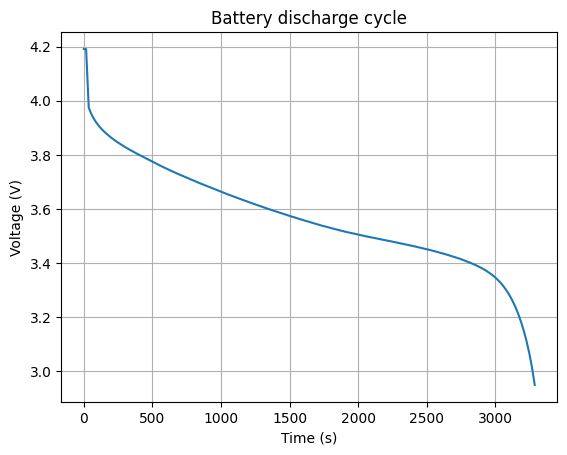


Downsampling every 5 points
t = 500 | Manual = 3.8117372364599302 | SciPy = 3.6957058114966594
t = 1500 | Manual = 3.5743014200245975 | SciPy = 2694998.41616698
t = 2500 | Manual = 3.4498344507862244 | SciPy = -95762354054.23528


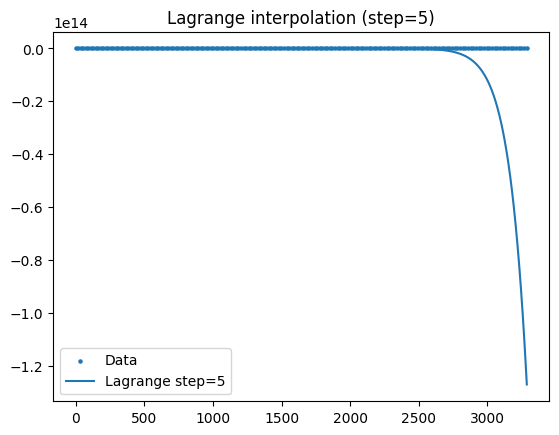


Downsampling every 10 points
t = 500 | Manual = 3.774169377277219 | SciPy = 3.7741693774491893
t = 1500 | Manual = 3.5743006647806137 | SciPy = 3.5743026955039565
t = 2500 | Manual = 3.4510584069098114 | SciPy = 3.450903851796129


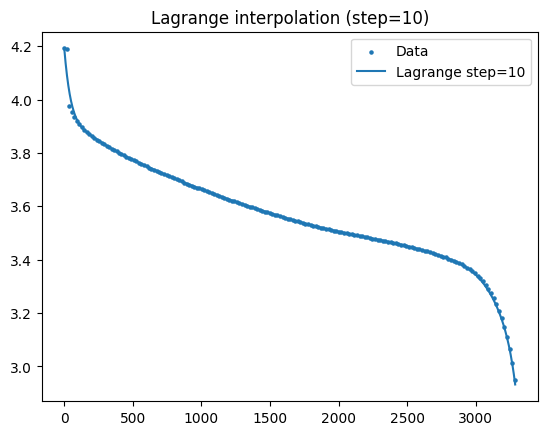


Downsampling every 20 points
t = 500 | Manual = 3.77055065880245 | SciPy = 3.7705506588023585
t = 1500 | Manual = 3.5743770851336882 | SciPy = 3.5743770851338534
t = 2500 | Manual = 3.452615027008797 | SciPy = 3.4526150270452254


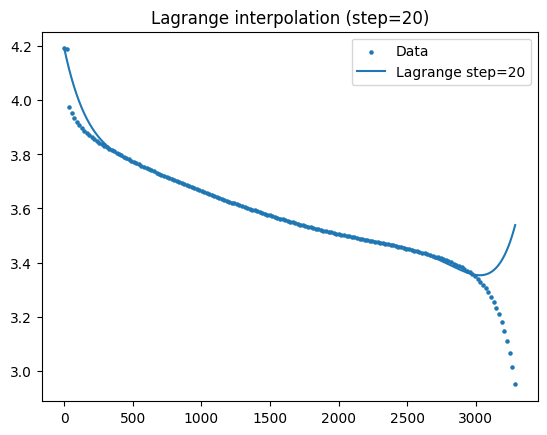


Extrapolation at 2500 s using limited data
Voltage = 2.2009236620010686


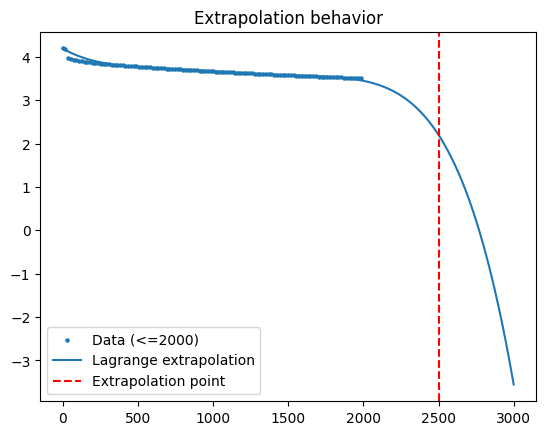


Cubic spline prediction at 2500 s
6.390041123562705


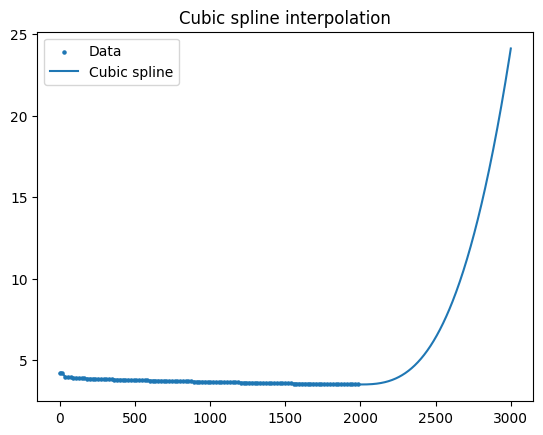


Regression prediction at 2500 s
2.4621934464721242


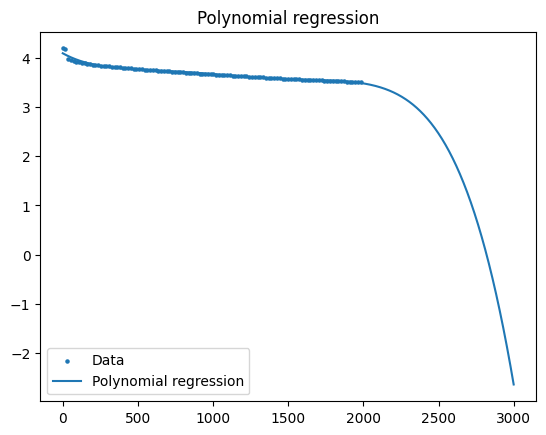


Time where voltage ≈ 3.0 V : 2002.2445485548556


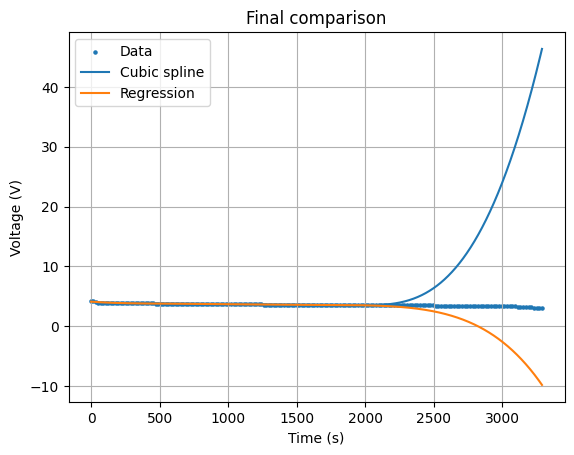

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline

# -------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------

data = pd.read_csv("battery_discharge.csv")  # Load CSV file

time = data["time"].values        # Extract time values
voltage = data["voltage"].values  # Extract voltage values
current = data["current"].values  # Extract current values


# -------------------------------------------------------
# 2. PLOT VOLTAGE VS TIME
# -------------------------------------------------------

plt.figure()
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Battery discharge cycle")
plt.grid()
plt.show()

# -------------------------------------------------------
# 3. LAGRANGE INTERPOLATION (manual)
# -------------------------------------------------------

def lagrange_manual(x_nodes, y_nodes, x):
    n = len(x_nodes)  # number of nodes
    P = 0             # initialize polynomial value

    for i in range(n):
        L = 1         # initialize basis polynomial

        for j in range(n):
            if i != j:
                L *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])

        P += y_nodes[i] * L

    return P


# -------------------------------------------------------
# 4. DOWNSAMPLING AND INTERPOLATION
# -------------------------------------------------------

targets = [500, 1500, 2500]   # target times
steps = [5, 10, 20]           # different downsampling levels

for step in steps:

    # Downsample data
    x_nodes = time[::step]
    y_nodes = voltage[::step]

    print("\nDownsampling every", step, "points")

    interpolated_values = []

    for t in targets:

        # Manual Lagrange interpolation
        v_manual = lagrange_manual(x_nodes, y_nodes, t)

        # SciPy Lagrange polynomial
        poly = lagrange(x_nodes, y_nodes)
        v_scipy = poly(t)

        print("t =", t, "| Manual =", v_manual, "| SciPy =", v_scipy)
        interpolated_values.append(v_scipy)

    # Plot interpolation behavior
    grid = np.linspace(min(time), max(time), 1000)
    plt.figure()
    plt.scatter(time, voltage, s=5, label="Data")
    plt.plot(grid, lagrange(x_nodes, y_nodes)(grid), label=f"Lagrange step={step}")
    plt.legend()
    plt.title(f"Lagrange interpolation (step={step})")
    plt.show()


# -------------------------------------------------------
# 5. EXTRAPOLATION
# -------------------------------------------------------

mask = time <= 2000  # restrict data

time_window = time[mask]
voltage_window = voltage[mask]

# Reduce number of nodes to avoid instability
x_small = time_window[::20]
y_small = voltage_window[::20]

poly = lagrange(x_small, y_small)

print("\nExtrapolation at 2500 s using limited data")
print("Voltage =", poly(2500))

# Plot extrapolation
grid_ext = np.linspace(0, 3000, 1000)
plt.figure()
plt.scatter(time_window, voltage_window, s=5, label="Data (<=2000)")
plt.plot(grid_ext, poly(grid_ext), label="Lagrange extrapolation")
plt.axvline(2500, color='r', linestyle='--', label="Extrapolation point")
plt.legend()
plt.title("Extrapolation behavior")
plt.show()


# -------------------------------------------------------
# 6. SPLINE INTERPOLATION (BETTER METHOD)
# -------------------------------------------------------

spline = CubicSpline(time_window, voltage_window)

print("\nCubic spline prediction at 2500 s")
print(spline(2500))

# Plot spline
plt.figure()
plt.scatter(time_window, voltage_window, s=5, label="Data")
plt.plot(grid_ext, spline(grid_ext), label="Cubic spline")
plt.legend()
plt.title("Cubic spline interpolation")
plt.show()


# -------------------------------------------------------
# 7. REGRESSION (Least Squares)
# -------------------------------------------------------

degree = 5
coef = np.polyfit(time_window, voltage_window, degree)
poly_reg = np.poly1d(coef)

print("\nRegression prediction at 2500 s")
print(poly_reg(2500))

# Plot regression
plt.figure()
plt.scatter(time_window, voltage_window, s=5, label="Data")
plt.plot(grid_ext, poly_reg(grid_ext), label="Polynomial regression")
plt.legend()
plt.title("Polynomial regression")
plt.show()


# -------------------------------------------------------
# 8. FIND TIME WHERE VOLTAGE = 3.0
# -------------------------------------------------------

target_voltage = 3.0

# Create dense grid
grid = np.linspace(min(time), max(time), 10000)

# Evaluate spline
interp_voltage = spline(grid)

# Find closest value
index = np.argmin(np.abs(interp_voltage - target_voltage))

# Extract corresponding time
t_solution = grid[index]

print("\nTime where voltage ≈ 3.0 V :", t_solution)


# -------------------------------------------------------
# 9. FINAL COMPARISON
# -------------------------------------------------------

plt.figure()

plt.scatter(time, voltage, s=5, label="Data")
plt.plot(grid, spline(grid), label="Cubic spline")
plt.plot(grid, poly_reg(grid), label="Regression")

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Final comparison")
plt.legend()
plt.grid()

plt.show()

In [3]:
''' ================================================assignment2===================================================================
    In this assignment, we analyzed Airbnb prices using linear regression models based on distance from the city center and number 
    of reviews.
    We first explored the data and observed a weak correlation between price and the selected variables.
    Then, we applied linear and quadratic regression models, solving the least squares problem using both normal equations and QR
    factorization.
    We observed that QR provides better numerical stability, especially when the data is not well conditioned.
    We also analyzed different room types and noticed different trends depending on the category.
    Finally, we combined distance and number of reviews into a single model, which slightly improved the prediction.
    In conclusion, modeling real data is challenging, and simple linear models are often not sufficient to capture all variations
'''

' ================================================assignment2===================================================================\n    In this assignment, we analyzed Airbnb prices using linear regression models based on distance from the city center and number \n    of reviews.\n    We first explored the data and observed a weak correlation between price and the selected variables.\n    Then, we applied linear and quadratic regression models, solving the least squares problem using both normal equations and QR\n    factorization.\n    We observed that QR provides better numerical stability, especially when the data is not well conditioned.\n    We also analyzed different room types and noticed different trends depending on the category.\n    Finally, we combined distance and number of reviews into a single model, which slightly improved the prediction.\n    In conclusion, modeling real data is challenging, and simple linear models are often not sufficient to capture all variations\n'

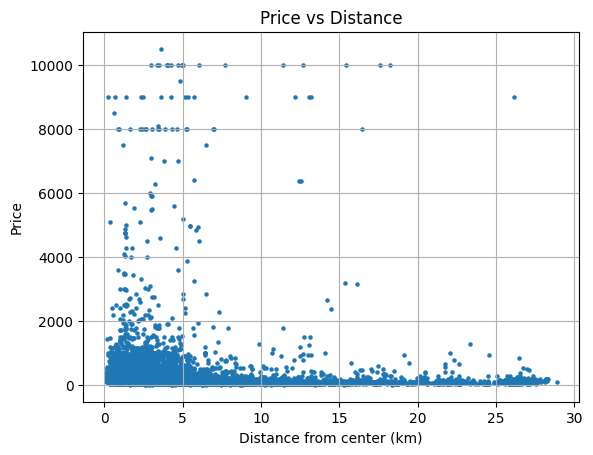

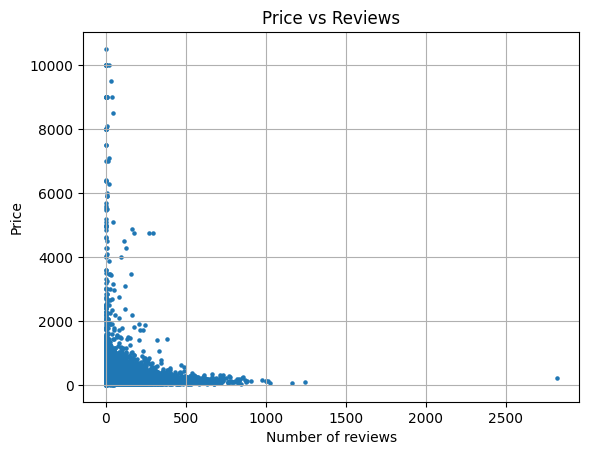

Coefficients (normal equations): [197.32800024 -23.92082983]
Coefficients (QR): [197.32800024 -23.92082983]


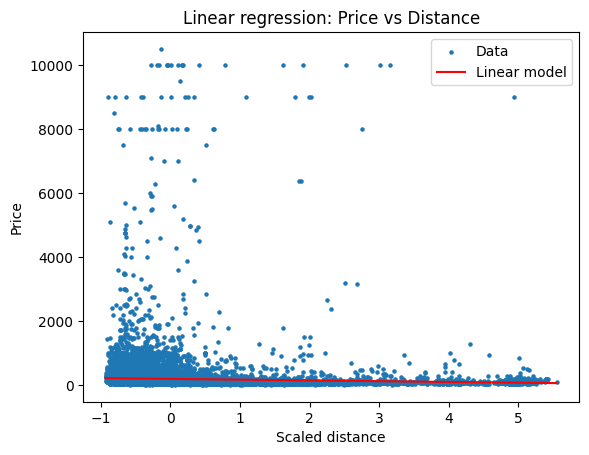

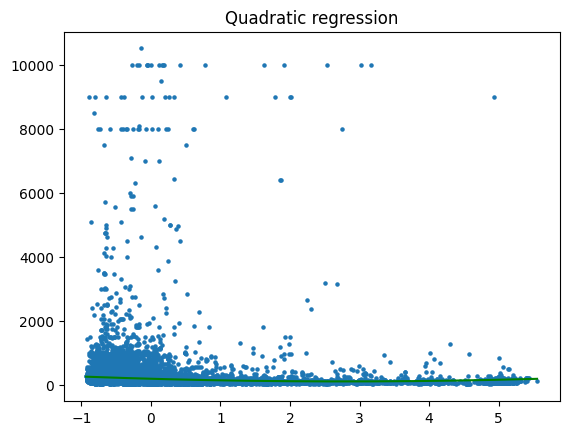

Condition number (original): 8.5403854169119
Condition number (scaled): 1.0000000000000009


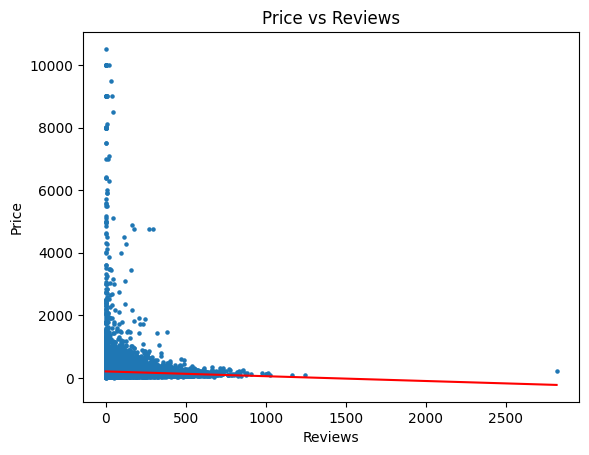

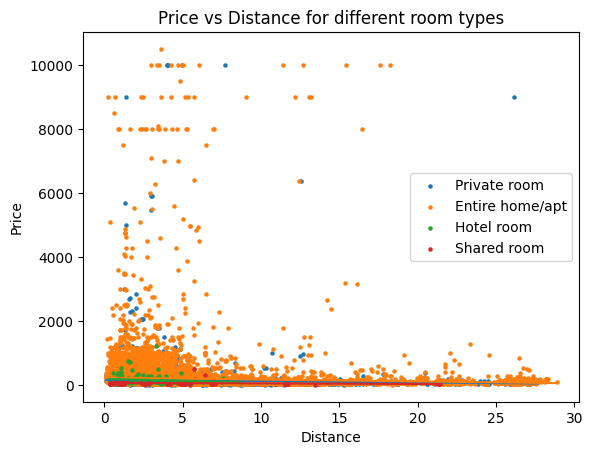

Residual p(d): 81075.06624424463
Residual p(r): 81143.27507401127
Residual p(d,r): 80993.64454924532


In [ ]:
import numpy as np  # Numerical computations
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Visualization

# -------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------

# Load and preprocess dataset

path = "listings-Rome.csv"

data = pd.read_csv(path)  # Load dataset

# Select relevant columns and drop missing values
cols = ["price","latitude","longitude","number_of_reviews","room_type"]
data = data[cols].dropna()  # Keep useful data only

# Convert price from string to float
data["price"] = data["price"].replace('[\$,]', '', regex=True).astype(float)  # Remove symbols and convert


# -------------------------------------------------------
# 2. COMPUTE DISTANCE FROM CITY CENTER
# -------------------------------------------------------

# Compute distance from city center

# Coordinates of city center (example: Rome)
lat_center = 41.9028
lon_center = 12.4964

def distance(lat, lon):
    # Approximate distance in km (better scaling than raw degrees)
    return np.sqrt(((lat-lat_center)*111)**2 + ((lon-lon_center)*85)**2)  # Convert degrees to km

data["distance"] = distance(data["latitude"], data["longitude"])  # Apply distance function


# -------------------------------------------------------
# 3. BASIC DATA VISUALIZATION
# -------------------------------------------------------

# Plot main relationships in data

plt.figure()
plt.scatter(data["distance"], data["price"], s=5)  # Distance vs price
plt.xlabel("Distance from center (km)")
plt.ylabel("Price")
plt.title("Price vs Distance")
plt.grid()
plt.show()

plt.figure()
plt.scatter(data["number_of_reviews"], data["price"], s=5)  # Reviews vs price
plt.xlabel("Number of reviews")
plt.ylabel("Price")
plt.title("Price vs Reviews")
plt.grid()
plt.show()


# -------------------------------------------------------
# 4. LINEAR REGRESSION : p(d) = a + b d
# -------------------------------------------------------

# Fit linear regression model

d = data["distance"].values  # Distance vector
price = data["price"].values  # Price vector

# Normalize distance for better conditioning
d_mean = np.mean(d)  # Mean of distances
d_std = np.std(d)  # Standard deviation
d_scaled = (d - d_mean)/d_std  # Standardization

A = np.column_stack((np.ones(len(d)), d_scaled))  # Build design matrix

# Normal equations
ATA = A.T @ A  # Compute A^T A
ATb = A.T @ price  # Compute A^T b
coeff_normal = np.linalg.solve(ATA, ATb)  # Solve linear system

print("Coefficients (normal equations):", coeff_normal)

# QR factorization
Q, R = np.linalg.qr(A)  # Decompose A = QR
coeff_qr = np.linalg.solve(R, Q.T @ price)  # Solve using QR

print("Coefficients (QR):", coeff_qr)

# Plot regression
d_grid = np.linspace(min(d_scaled), max(d_scaled), 200)  # Generate smooth x-axis
p_pred = coeff_qr[0] + coeff_qr[1]*d_grid  # Compute predicted values

plt.figure()
plt.scatter(d_scaled, price, s=5, label="Data")
plt.plot(d_grid, p_pred, color="red", label="Linear model")
plt.xlabel("Scaled distance")
plt.ylabel("Price")
plt.legend()
plt.title("Linear regression: Price vs Distance")
plt.show()


# -------------------------------------------------------
# 5. QUADRATIC MODEL : p(d)=a+bd+cd^2
# -------------------------------------------------------

# Fit quadratic regression model

A2 = np.column_stack((np.ones(len(d)), d_scaled, d_scaled**2))  # Add quadratic term

Q, R = np.linalg.qr(A2)
coeff_quad = np.linalg.solve(R, Q.T @ price)  # Solve system

p_quad = coeff_quad[0] + coeff_quad[1]*d_grid + coeff_quad[2]*d_grid**2  # Compute predictions

plt.figure()
plt.scatter(d_scaled, price, s=5)
plt.plot(d_grid, p_quad, color="green")
plt.title("Quadratic regression")
plt.show()


# -------------------------------------------------------
# 6. CONDITION NUMBER
# -------------------------------------------------------

# Check numerical stability of matrices

cond_original = np.linalg.cond(np.column_stack((np.ones(len(d)), d)))  # Without scaling
cond_scaled = np.linalg.cond(A)  # With scaling

print("Condition number (original):", cond_original)
print("Condition number (scaled):", cond_scaled)


# -------------------------------------------------------
# 7. MODEL USING REVIEWS : p(r)
# -------------------------------------------------------

# Fit regression model with reviews

r = data["number_of_reviews"].values  # Reviews vector

A_reviews = np.column_stack((np.ones(len(r)), r))  # Build matrix

Q, R = np.linalg.qr(A_reviews)
coeff_reviews = np.linalg.solve(R, Q.T @ price)  # Solve QR system

r_grid = np.linspace(min(r), max(r), 200)  # Generate values
p_reviews = coeff_reviews[0] + coeff_reviews[1]*r_grid  # Predict values

plt.figure()
plt.scatter(r, price, s=5)
plt.plot(r_grid, p_reviews, color="red")
plt.xlabel("Reviews")
plt.ylabel("Price")
plt.title("Price vs Reviews")
plt.show()


# -------------------------------------------------------
# 8. SEPARATE ROOM TYPES
# -------------------------------------------------------

# Fit separate model for each room type

room_types = data["room_type"].unique()  # Get unique categories

plt.figure()

for room in room_types:  # Iterate over room types

    subset = data[data["room_type"] == room]  # Filter data

    d_room = subset["distance"].values  # Distance for subset
    p_room = subset["price"].values  # Price for subset

    A_room = np.column_stack((np.ones(len(d_room)), d_room))  # Build matrix

    Q, R = np.linalg.qr(A_room)
    coeff = np.linalg.solve(R, Q.T @ p_room)  # Compute coefficients

    d_grid = np.linspace(min(d_room), max(d_room), 200)  # Generate values
    p_pred = coeff[0] + coeff[1]*d_grid  # Compute prediction

    plt.scatter(d_room, p_room, s=5, label=room)
    plt.plot(d_grid, p_pred)

plt.xlabel("Distance")
plt.ylabel("Price")
plt.legend()
plt.title("Price vs Distance for different room types")
plt.show()


# -------------------------------------------------------
# 9. MODEL p(d,r)
# -------------------------------------------------------

# Fit multivariate regression model

A_full = np.column_stack((np.ones(len(d)), d_scaled, r))  # Combine variables

Q, R = np.linalg.qr(A_full)
coeff_full = np.linalg.solve(R, Q.T @ price)  # Solve system

p_full = coeff_full[0] + coeff_full[1]*d_scaled + coeff_full[2]*r  # Compute predictions

# Compute residuals
res_dist = np.linalg.norm(price - (coeff_qr[0] + coeff_qr[1]*d_scaled))  # Error for distance model
res_reviews = np.linalg.norm(price - (coeff_reviews[0] + coeff_reviews[1]*r))  # Error for reviews model
res_full = np.linalg.norm(price - p_full)  # Error for full model

print("Residual p(d):", res_dist)
print("Residual p(r):", res_reviews)
print("Residual p(d,r):", res_full)

In [5]:
''' ========================================assignment3===================================================
    In this assignment, we addressed the image deblurring problem by modeling it as a linear system.
    First, we applied a Gaussian blur to a grayscale image and constructed the corresponding matrix 
    representation of the convolution operator.
    Then, we solved the system using a direct method and two iterative methods: Jacobi and Gauss-Seidel.
    We observed that Gauss-Seidel converges faster than Jacobi, while the direct solver gives an exact 
    solution but is computationally expensive.
    We also evaluated the reconstruction quality using the mean squared error.
    Finally, we added noise to the blurred image and noticed a significant degradation of the reconstruction
    showing that the problem is ill-posed.
    In conclusion, iterative methods are useful, but regularization techniques are necessary for better stability
'''

' ========================================assignment3===================================================\n    In this assignment, we addressed the image deblurring problem by modeling it as a linear system.\n    First, we applied a Gaussian blur to a grayscale image and constructed the corresponding matrix \n    representation of the convolution operator.\n    Then, we solved the system using a direct method and two iterative methods: Jacobi and Gauss-Seidel.\n    We observed that Gauss-Seidel converges faster than Jacobi, while the direct solver gives an exact \n    solution but is computationally expensive.\n    We also evaluated the reconstruction quality using the mean squared error.\n    Finally, we added noise to the blurred image and noticed a significant degradation of the reconstruction\n    showing that the problem is ill-posed.\n    In conclusion, iterative methods are useful, but regularization techniques are necessary for better stability\n'

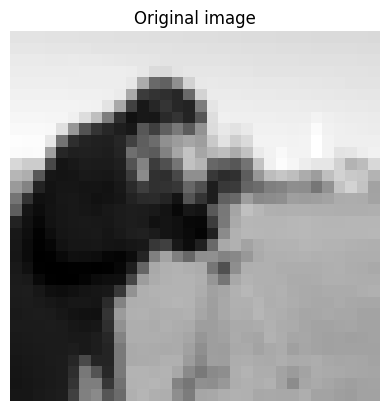

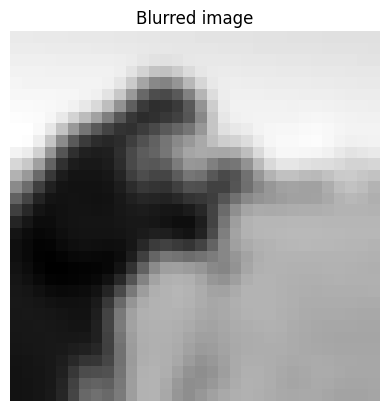

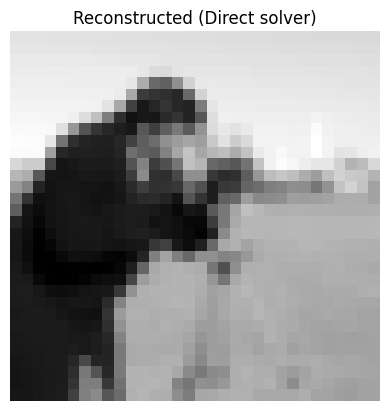

MSE Direct: 1.7610434651855787e-27
MSE Jacobi: 9.212686070420314e+140
MSE Gauss-Seidel: 6.947589475704097e-07


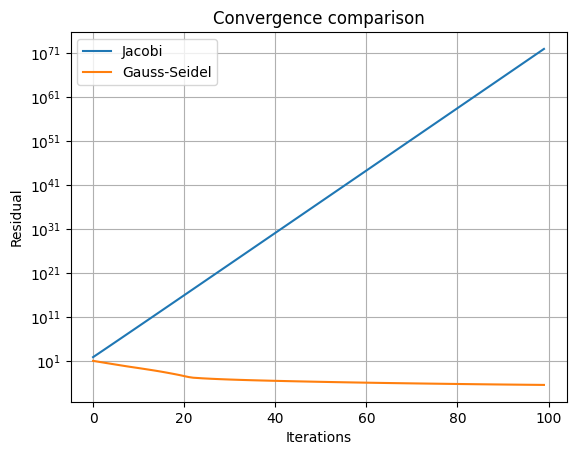

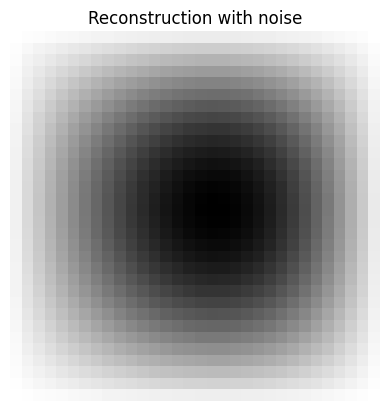

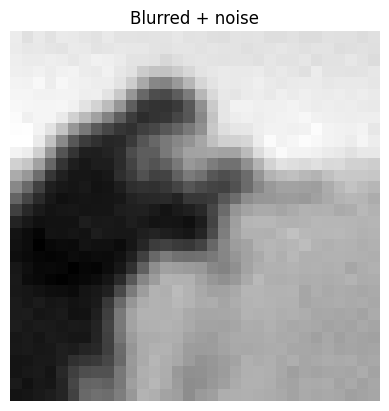

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy.signal import convolve2d
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from skimage.transform import resize
from scipy.sparse import diags

# -------------------------------------------------------
# 1. LOAD AND DOWNSAMPLE IMAGE
# -------------------------------------------------------

image = img_as_float(data.camera())  # Load grayscale test image

image = resize(image, (32, 32))  # Reduce image size for computational efficiency

n, m = image.shape  # Image dimensions
N = n * m           # Total number of pixels

plt.imshow(image, cmap='gray')
plt.title("Original image")
plt.axis("off")
plt.show()

# -------------------------------------------------------
# 2. GAUSSIAN BLUR KERNEL
# -------------------------------------------------------

def gaussian_kernel(size=5, sigma=1):
    # Create a Gaussian kernel
    ax = np.arange(-size//2 + 1., size//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()  # Normalize kernel

kernel = gaussian_kernel(5, 1)

# -------------------------------------------------------
# 3. APPLY BLUR
# -------------------------------------------------------

blurred = convolve2d(image, kernel, mode='same', boundary='symm')  
# Apply convolution to simulate blur

plt.imshow(blurred, cmap='gray')
plt.title("Blurred image")
plt.axis("off")
plt.show()

# -------------------------------------------------------
# 4. BUILD MATRIX A
# -------------------------------------------------------

A = lil_matrix((N, N))  # Sparse matrix

# Build convolution matrix column by column
for j in range(N):

    basis = np.zeros((n, m))  # Create basis image
    basis.flat[j] = 1         # Set one pixel to 1

    conv = convolve2d(basis, kernel, mode='same', boundary='symm')

    A[:, j] = conv.flatten()  # Fill column j with convolution result

A = A.tocsr()  # Convert to efficient sparse format

b = blurred.flatten()  # Vectorized blurred image

# -------------------------------------------------------
# 5. DIRECT SOLVER
# -------------------------------------------------------

x_direct = spsolve(A, b)  # Solve Ax=b

reconstructed_direct = x_direct.reshape((n, m))

plt.imshow(reconstructed_direct, cmap='gray')
plt.title("Reconstructed (Direct solver)")
plt.axis("off")
plt.show()

# -------------------------------------------------------
# 6. JACOBI METHOD
# -------------------------------------------------------

def jacobi(A, b, max_iter=100, tol=1e-6):

    x = np.zeros_like(b)  # initial guess

    D = A.diagonal().copy()   # get diagonal as vector
    D_mat = diags(D)          # sparse diagonal matrix

    R = A - D_mat             # remainder matrix

    residuals = []

    for i in range(max_iter):

        x_new = (b - R @ x) / D  # Jacobi update

        res = np.linalg.norm(A @ x_new - b)
        residuals.append(res)

        if res < tol:
            break

        x = x_new

    return x, residuals
x_jacobi, res_jacobi = jacobi(A, b)
img_jacobi = x_jacobi.reshape((n, m))

# -------------------------------------------------------
# 7. GAUSS-SEIDEL METHOD
# -------------------------------------------------------

def gauss_seidel(A, b, max_iter=100, tol=1e-6):

    x = np.zeros_like(b)
    residuals = []

    for k in range(max_iter):

        for i in range(len(b)):

            row = A.getrow(i).toarray().flatten()

            sigma = row @ x - row[i] * x[i]

            x[i] = (b[i] - sigma) / row[i]

        res = np.linalg.norm(A @ x - b)
        residuals.append(res)

        if res < tol:
            break

    return x, residuals

x_gs, res_gs = gauss_seidel(A, b)

img_gs = x_gs.reshape((n, m))

# -------------------------------------------------------
# 8. ERROR (MSE)
# -------------------------------------------------------

def mse(a, b):
    return np.mean((a - b) ** 2)

print("MSE Direct:", mse(image, reconstructed_direct))
print("MSE Jacobi:", mse(image, img_jacobi))
print("MSE Gauss-Seidel:", mse(image, img_gs))

# -------------------------------------------------------
# 9. CONVERGENCE PLOT
# -------------------------------------------------------

plt.plot(res_jacobi, label="Jacobi")
plt.plot(res_gs, label="Gauss-Seidel")
plt.yscale("log")  # Log scale for convergence visualization
plt.xlabel("Iterations")
plt.ylabel("Residual")
plt.legend()
plt.title("Convergence comparison")
plt.grid()
plt.show()

# -------------------------------------------------------
# 10. BONUS: ADD NOISE
# -------------------------------------------------------

noise = 0.01 * np.random.randn(*blurred.shape)  # Add Gaussian noise

blurred_noisy = blurred + noise

b_noise = blurred_noisy.flatten()

x_noise, _ = jacobi(A, b_noise)

img_noise = x_noise.reshape((n, m))

plt.imshow(img_noise, cmap='gray')
plt.title("Reconstruction with noise")
plt.axis("off")
plt.show()

# Compare noisy input vs reconstruction
plt.figure()
plt.imshow(blurred_noisy, cmap='gray')
plt.title("Blurred + noise")
plt.axis("off")
plt.show()